# Moore's Law Visualization

This notebook loads processor transistor count data and visualizes the exponential growth over time (Moore's Law).

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

FIGURE_DIR = Path("../../book/book/images")
assert FIGURE_DIR.exists(), f"Figure directory {FIGURE_DIR} does not exist"

## Load the Data

Load the processor transistor count data from the CSV file.

In [16]:
# Load the data
data_path = '../src/bettercode/data/mooreslaw/processor_transistor_counts.csv'
df = pd.read_csv(data_path)

# Display first few rows
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (247, 7)


,Processor,Transistor count,Year,Designer,Process (nm),Area (mm2),Transistor density (tr./mm2)
0,"MP944 (20-bit, 6-chip, 28 chips total)","74,442 (5,360 excl. ROM & RAM)",1970,Garrett AiResearch,?,?,?
1,"Intel 4004 (4-bit, 16-pin)","2,250",1971,Intel,"10,000 nm",12 mm2,188
2,"TMX 1795 (8-bit, 24-pin)","3,078",1971,Texas Instruments,?,30.64 mm2,100.5
3,"Intel 8008 (8-bit, 18-pin)","3,500",1972,Intel,"10,000 nm",14 mm2,250
4,"NEC μCOM-4 (4-bit, 42-pin)","2,500",1973,NEC,"7,500 nm",?,?


## Data Preprocessing

Clean the transistor count column by removing commas and converting to numeric values.

In [17]:
# Clean the transistor count column
# Remove commas and extract the first number if there are multiple values
df['Transistor count'] = df['Transistor count'].astype(str).str.replace(',', '')
df['Transistor count'] = df['Transistor count'].str.extract(r'(\d+)')[0].astype(float)

# Remove rows with missing transistor counts or years
df_clean = df.dropna(subset=['Transistor count', 'Year'])

print(f"Clean dataset shape: {df_clean.shape}")
df_clean.head()

Clean dataset shape: (246, 7)


,Processor,Transistor count,Year,Designer,Process (nm),Area (mm2),Transistor density (tr./mm2)
0,"MP944 (20-bit, 6-chip, 28 chips total)",74442.0,1970,Garrett AiResearch,?,?,?
1,"Intel 4004 (4-bit, 16-pin)",2250.0,1971,Intel,"10,000 nm",12 mm2,188
2,"TMX 1795 (8-bit, 24-pin)",3078.0,1971,Texas Instruments,?,30.64 mm2,100.5
3,"Intel 8008 (8-bit, 18-pin)",3500.0,1972,Intel,"10,000 nm",14 mm2,250
4,"NEC μCOM-4 (4-bit, 42-pin)",2500.0,1973,NEC,"7,500 nm",?,?


## Plot Log Transistor Count vs Year

Create a scatter plot showing the logarithmic relationship between transistor count and year, demonstrating Moore's Law.

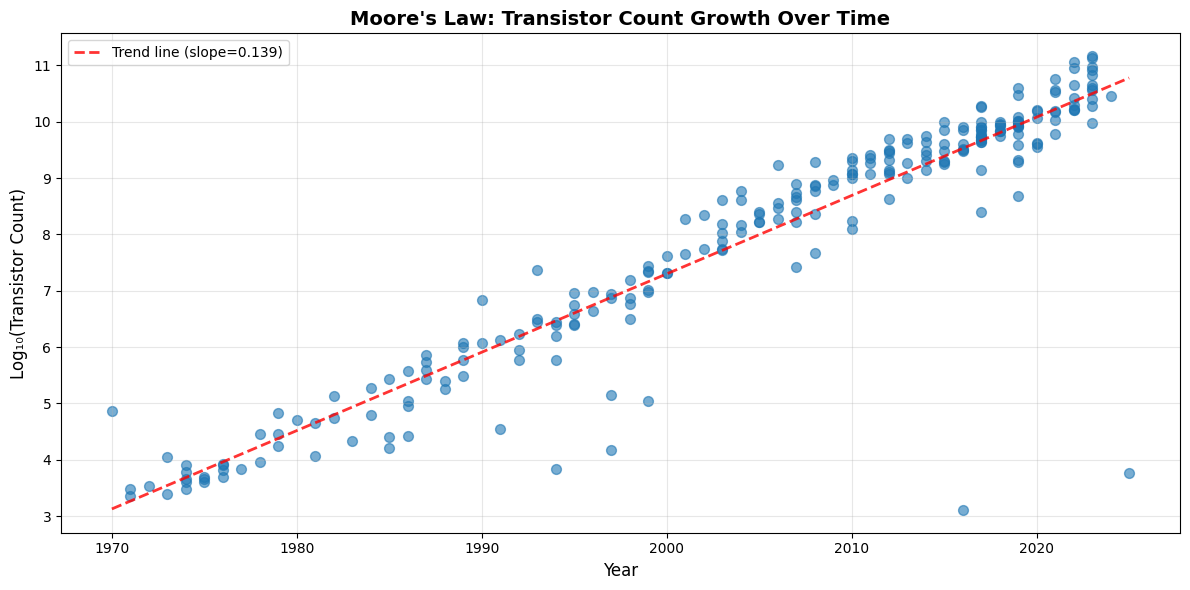

In [18]:
# Create the plot
plt.figure(figsize=(12, 6))
plt.scatter(df_clean['Year'], np.log10(df_clean['Transistor count']), alpha=0.6, s=50)

# Add labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Log₁₀(Transistor Count)', fontsize=12)
plt.title('Moore\'s Law: Transistor Count Growth Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add a trend line
z = np.polyfit(df_clean['Year'], np.log10(df_clean['Transistor count']), 1)
p = np.poly1d(z)
plt.plot(df_clean['Year'], p(df_clean['Year']), 'r--', alpha=0.8, linewidth=2, label=f'Trend line (slope={z[0]:.3f})')
plt.legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'moores_law_plot.png', dpi=300)
plt.show()

## Calculate Doubling Time

Moore's Law predicts that transistor counts double approximately every 2 years. Let's verify this from our data.

In [19]:
# Calculate doubling time from the slope
# The slope is in log10 units per year
# Doubling means log10(2) = 0.301 increase
doubling_time = 0.301 / z[0]

print(f"Slope of log₁₀(transistor count) vs year: {z[0]:.4f}")
print(f"Estimated doubling time: {doubling_time:.2f} years")
print(f"\nMoore's Law prediction: ~2 years")
print(f"Observed from data: ~{doubling_time:.2f} years")

Slope of log₁₀(transistor count) vs year: 0.1390
Estimated doubling time: 2.16 years

Moore's Law prediction: ~2 years
Observed from data: ~2.16 years


### Top500 performance

In [20]:
top500_file = '../src/bettercode/data/mooreslaw/top500_performance.csv'
top500_df = pd.read_csv(top500_file)
drop_cols = ['Power efficiency (GFLOPS per Watt)', 'Unnamed: 5',
       'Unnamed: 6']
top500_df = top500_df.drop(columns=drop_cols)

top500_df.head()

,Year,Supercomputer,Peak speed (Rmax),Location
0,1993,Fujitsu Numerical Wind Tunnel,124.50 GFLOPS,National Aerospace Laboratory
1,1993,Intel Paragon XP/S 140,143.40 GFLOPS,DoE-Sandia National Laboratories
2,1994,Fujitsu Numerical Wind Tunnel,170.40 GFLOPS,National Aerospace Laboratory
3,1996,Hitachi SR2201/1024,220.40 GFLOPS,University of Tokyo
4,1996,Hitachi CP-PACS/2048,368.20 GFLOPS,University of Tsukuba


In [21]:
top500_df.columns

Index(['Year', 'Supercomputer', 'Peak speed (Rmax)', 'Location'], dtype='object')

In [22]:
# Check unique units in the Peak speed column
units = top500_df['Peak speed (Rmax)'].str.extract(r'(GFLOPS|TFLOPS|PFLOPS|EFLOPS)')[0].unique()
print("Units found:", units)
print("\nSample values:")
print(top500_df['Peak speed (Rmax)'].head(10))

Units found: ['GFLOPS' 'TFLOPS' 'PFLOPS' 'EFLOPS']

Sample values:
0    124.50 GFLOPS
1    143.40 GFLOPS
2    170.40 GFLOPS
3    220.40 GFLOPS
4    368.20 GFLOPS
5     1.338 TFLOPS
6    2.3796 TFLOPS
7     7.226 TFLOPS
8    35.860 TFLOPS
9    70.720 TFLOPS
Name: Peak speed (Rmax), dtype: object


In [23]:
# Convert Peak speed to GFLOPS
def convert_to_gflops(speed_str):
    """Convert speed string to GFLOPS"""
    # Extract numeric value and unit
    parts = speed_str.strip().split()
    value = float(parts[0])
    unit = parts[1]
    
    # Conversion factors to GFLOPS
    conversions = {
        'GFLOPS': 1,
        'TFLOPS': 1e3,      # 1 TFLOPS = 1000 GFLOPS
        'PFLOPS': 1e6,      # 1 PFLOPS = 1,000,000 GFLOPS
        'EFLOPS': 1e9       # 1 EFLOPS = 1,000,000,000 GFLOPS
    }
    
    return value * conversions[unit]

# Create new column with values in GFLOPS
top500_df['Peak speed (GFLOPS)'] = top500_df['Peak speed (Rmax)'].apply(convert_to_gflops)

# Display the results
print("Conversion complete!")
print("\nSample conversions:")
comparison = top500_df[['Year', 'Supercomputer', 'Peak speed (Rmax)', 'Peak speed (GFLOPS)']].head(10)
print(comparison.to_string())

Conversion complete!

Sample conversions:
   Year                  Supercomputer Peak speed (Rmax)  Peak speed (GFLOPS)
0  1993  Fujitsu Numerical Wind Tunnel     124.50 GFLOPS                124.5
1  1993         Intel Paragon XP/S 140     143.40 GFLOPS                143.4
2  1994  Fujitsu Numerical Wind Tunnel     170.40 GFLOPS                170.4
3  1996            Hitachi SR2201/1024     220.40 GFLOPS                220.4
4  1996           Hitachi CP-PACS/2048     368.20 GFLOPS                368.2
5  1997            Intel ASCI Red/9152      1.338 TFLOPS               1338.0
6  1999            Intel ASCI Red/9632     2.3796 TFLOPS               2379.6
7  2000                 IBM ASCI White      7.226 TFLOPS               7226.0
8  2002            NEC Earth Simulator     35.860 TFLOPS              35860.0
9  2004                IBM Blue Gene/L     70.720 TFLOPS              70720.0


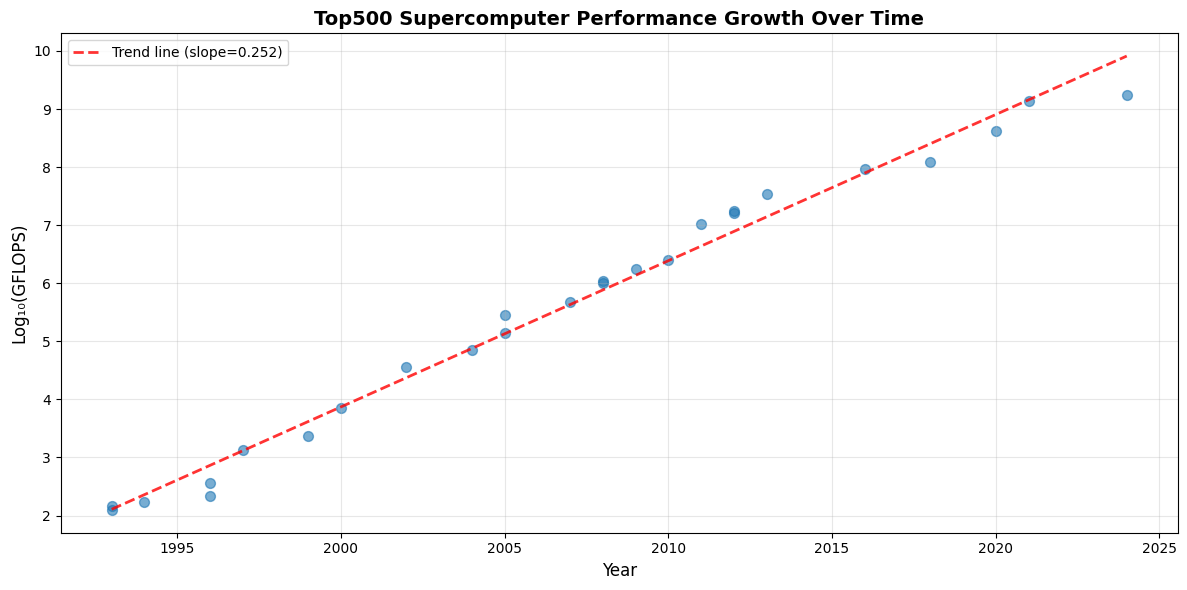


Slope of log₁₀(GFLOPS) vs year: 0.2518
Estimated doubling time: 1.20 years


In [25]:
# Create plot of log(GFLOPS) vs Year
plt.figure(figsize=(12, 6))
plt.scatter(top500_df['Year'], np.log10(top500_df['Peak speed (GFLOPS)']), alpha=0.6, s=50)

# Add labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Log₁₀(GFLOPS)', fontsize=12)
plt.title('Top500 Supercomputer Performance Growth Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add a trend line
z_top500 = np.polyfit(top500_df['Year'], np.log10(top500_df['Peak speed (GFLOPS)']), 1)
p_top500 = np.poly1d(z_top500)
plt.plot(top500_df['Year'], p_top500(top500_df['Year']), 'r--', alpha=0.8, linewidth=2, 
         label=f'Trend line (slope={z_top500[0]:.3f})')
plt.legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'top500_performance_plot.png', dpi=300)
plt.show()

# Calculate doubling time for supercomputer performance
doubling_time_top500 = 0.301 / z_top500[0]
print(f"\nSlope of log₁₀(GFLOPS) vs year: {z_top500[0]:.4f}")
print(f"Estimated doubling time: {doubling_time_top500:.2f} years")

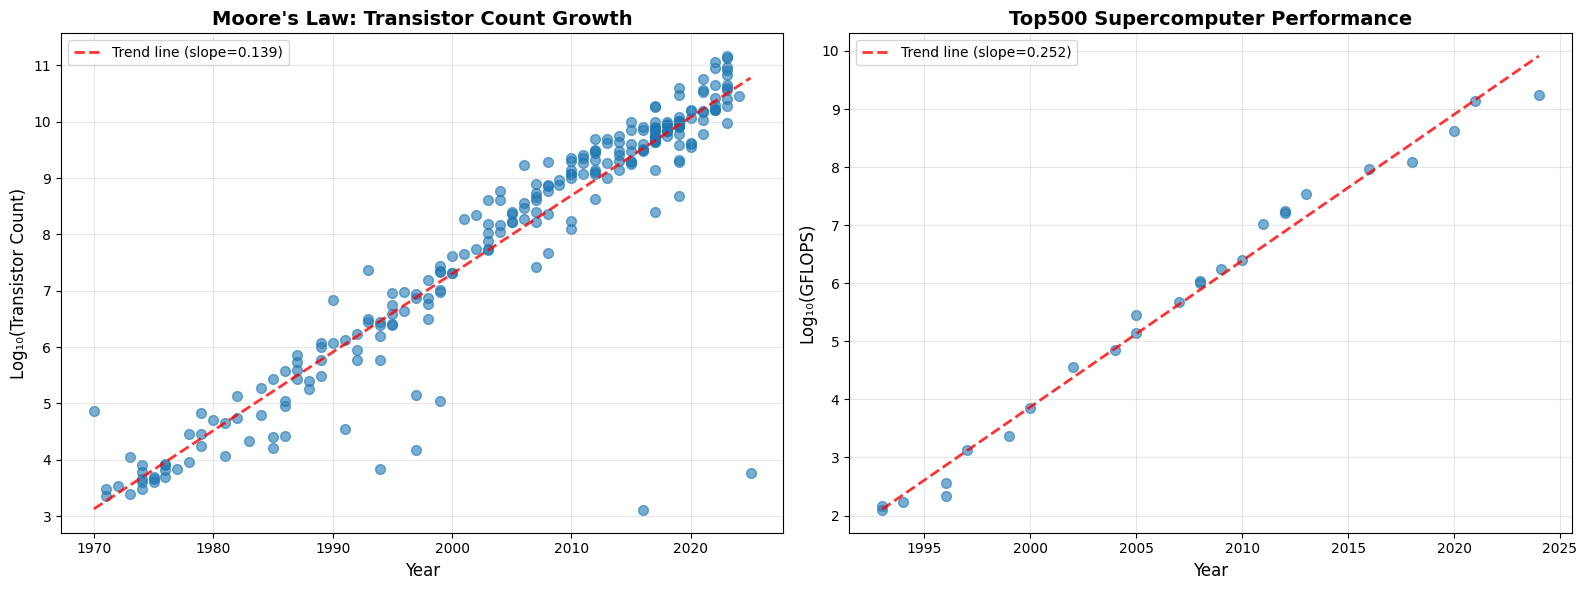

Comparison of Growth Rates:

Transistor Count (Moore's Law):
  Slope: 0.1390
  Doubling time: 2.16 years

Top500 Performance:
  Slope: 0.2518
  Doubling time: 1.20 years


In [26]:
# Create two-panel plot comparing Moore's Law and Top500 performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Transistor counts (Moore's Law)
ax1.scatter(df_clean['Year'], np.log10(df_clean['Transistor count']), alpha=0.6, s=50)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Log₁₀(Transistor Count)', fontsize=12)
ax1.set_title('Moore\'s Law: Transistor Count Growth', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add trend line for transistors
z = np.polyfit(df_clean['Year'], np.log10(df_clean['Transistor count']), 1)
p = np.poly1d(z)
ax1.plot(df_clean['Year'], p(df_clean['Year']), 'r--', alpha=0.8, linewidth=2, 
         label=f'Trend line (slope={z[0]:.3f})')
ax1.legend()

# Right panel: Top500 supercomputer performance
ax2.scatter(top500_df['Year'], np.log10(top500_df['Peak speed (GFLOPS)']), alpha=0.6, s=50)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Log₁₀(GFLOPS)', fontsize=12)
ax2.set_title('Top500 Supercomputer Performance', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add trend line for Top500
z_top500 = np.polyfit(top500_df['Year'], np.log10(top500_df['Peak speed (GFLOPS)']), 1)
p_top500 = np.poly1d(z_top500)
ax2.plot(top500_df['Year'], p_top500(top500_df['Year']), 'r--', alpha=0.8, linewidth=2, 
         label=f'Trend line (slope={z_top500[0]:.3f})')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'moores_law_comparison.png', dpi=300)
plt.show()

# Print comparison
print("Comparison of Growth Rates:")
print(f"\nTransistor Count (Moore's Law):")
print(f"  Slope: {z[0]:.4f}")
print(f"  Doubling time: {0.301 / z[0]:.2f} years")
print(f"\nTop500 Performance:")
print(f"  Slope: {z_top500[0]:.4f}")
print(f"  Doubling time: {0.301 / z_top500[0]:.2f} years")

In [30]:
# Calculate how long a 1-hour simulation on the latest supercomputer would take in 1994

# Get the most recent supercomputer performance
latest_year = top500_df['Year'].max()
latest_performance = top500_df[top500_df['Year'] == latest_year]['Peak speed (GFLOPS)'].max()

# Get the 1994 supercomputer performance
perf_1994 = top500_df[top500_df['Year'] == 1994]['Peak speed (GFLOPS)'].max()

# Calculate the ratio
performance_ratio = latest_performance / perf_1994

# Calculate time for 1994 (assuming linear relationship with performance)
simtime = 1/60 # one minute on latest
time_1994_hours = simtime * performance_ratio
time_1994_days = time_1994_hours / 24
time_1994_years = time_1994_days / 365.25

print(f"Most recent supercomputer ({latest_year}):")
print(f"  Performance: {latest_performance:,.0f} GFLOPS")
print(f"\n1994 supercomputer:")
print(f"  Performance: {perf_1994:,.0f} GFLOPS")
print(f"\nPerformance ratio: {performance_ratio:,.0f}x")
print(f"\nIf a simulation takes {simtime*60} minutes on the {latest_year} supercomputer,")
print(f"it would have taken on the 1994 supercomputer:")
print(f"  {time_1994_hours:,.0f} hours")
print(f"  {time_1994_days:,.1f} days")
print(f"  {time_1994_years:,.2f} years")

Most recent supercomputer (2024):
  Performance: 1,742,000,000 GFLOPS

1994 supercomputer:
  Performance: 170 GFLOPS

Performance ratio: 10,223,005x

If a simulation takes 1.0 minutes on the 2024 supercomputer,
it would have taken on the 1994 supercomputer:
  170,383 hours
  7,099.3 days
  19.44 years
